# Unemployment Analysis with Python

## Objective

This project analyzes unemployment trends in India using Python.
The analysis focuses on regional differences, monthly trends, and
the impact of the COVID-19 pandemic on unemployment rates.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the unemployment dataset
import pandas as pd

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
# Inspect the dataset
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (267, 9)

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                     object
longitude                                   float64
latitude                                    float64
dtype: object

Missing Values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [5]:
# Clean column names
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [6]:
# Convert numerical columns to numeric data types

numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object


In [7]:
# Convert numerical columns to numeric data types

numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object


In [8]:
# Display descriptive statistics

df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [9]:
# Calculate average unemployment rate for each region

region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate by Region:")
print(region_avg)

Average Unemployment Rate by Region:
Region
Andhra Pradesh       8.664000
Assam                4.856000
Bihar               19.471000
Chhattisgarh         7.819000
Delhi               18.414000
Goa                 12.167000
Gujarat              6.376000
Haryana             27.477000
Himachal Pradesh    16.065000
Jammu & Kashmir     16.477778
Jharkhand           19.539000
Karnataka            7.668000
Kerala               9.434000
Madhya Pradesh       6.854000
Maharashtra          7.979000
Meghalaya            3.866000
Odisha               6.462000
Puducherry          17.942000
Punjab              11.981000
Rajasthan           15.868000
Sikkim               9.792500
Tamil Nadu          12.187000
Telangana            6.833000
Tripura             25.055000
Uttar Pradesh        9.737000
Uttarakhand         11.156000
West Bengal         10.192000
Name: Estimated Unemployment Rate (%), dtype: float64


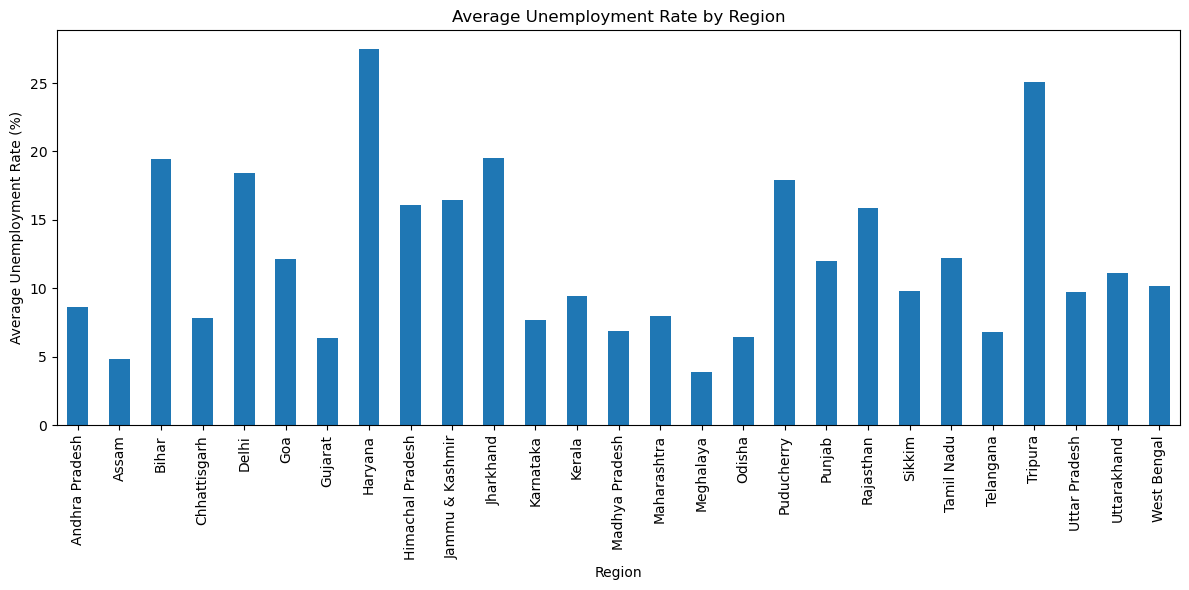

In [10]:
# Plot average unemployment rate by region

plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()



In [12]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Create a month column
df["Month"] = df["Date"].dt.to_period("M")

# Calculate monthly average unemployment rate
monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

print(monthly_avg)

Month
2020-01     9.196538
2020-02     9.266154
2020-03    10.782593
2020-04    22.236154
2020-05    23.244444
2020-06    10.911111
2020-07     9.834444
2020-08    10.313333
2020-09     8.705926
2020-10     8.026296
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64


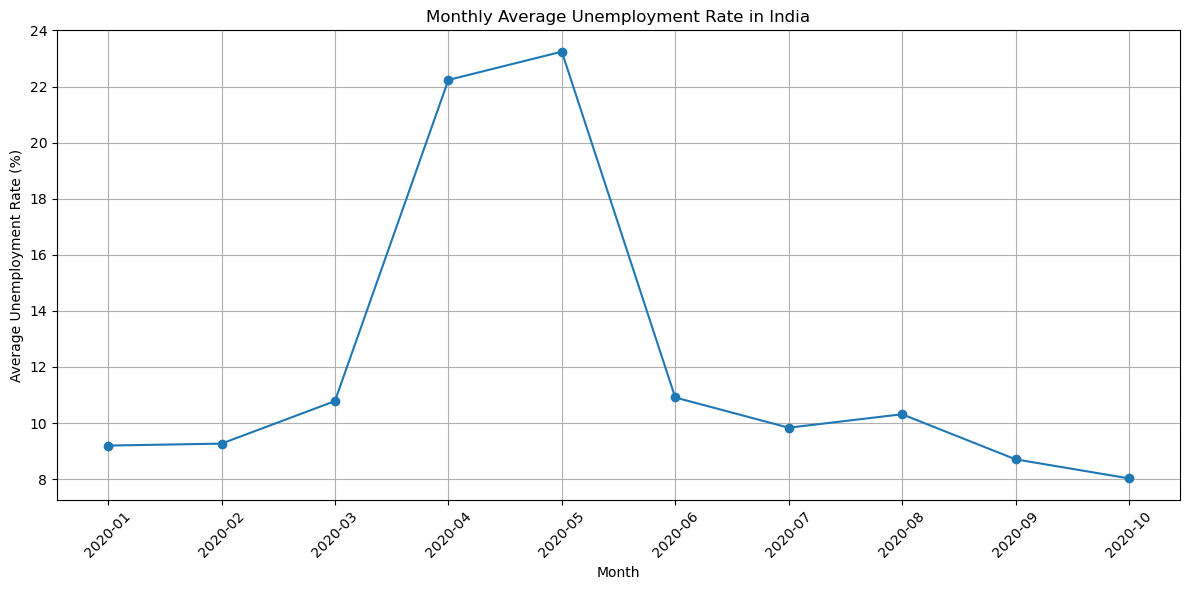

In [14]:
# Plot monthly average unemployment rate

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index.astype(str),
    monthly_avg.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

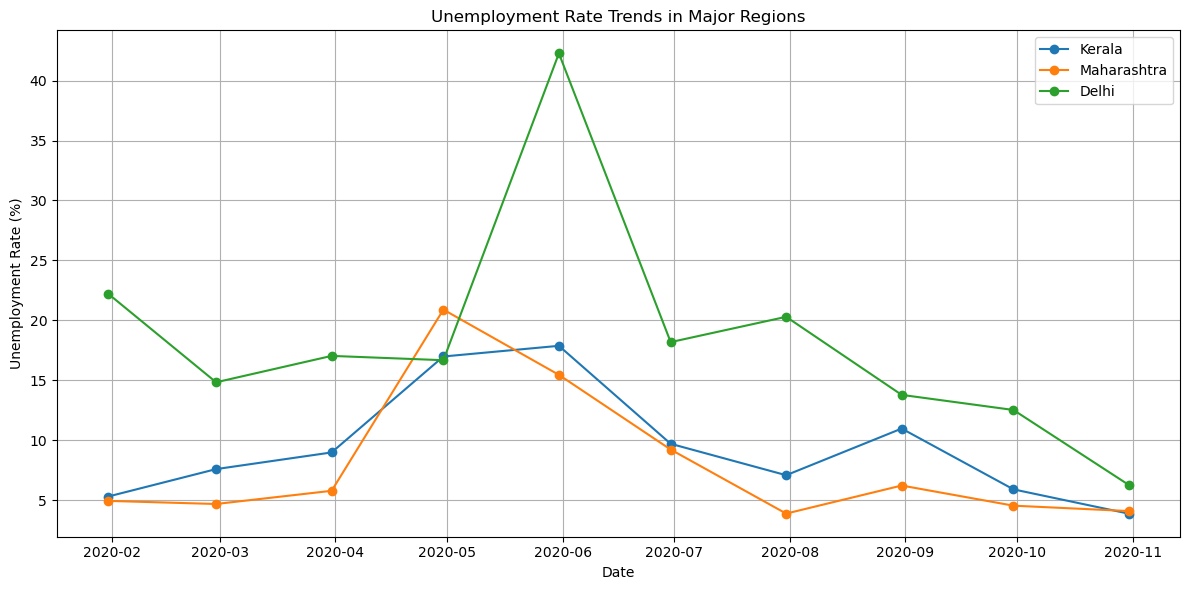

In [15]:
# Select three major regions
major_regions = ["Kerala", "Maharashtra", "Delhi"]

# Filter the dataset
region_data = df[df["Region"].isin(major_regions)]

# Plot unemployment trends
plt.figure(figsize=(12, 6))

for region in major_regions:
    data = region_data[region_data["Region"] == region]
    plt.plot(
        data["Date"],
        data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Trends in Major Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Find the top 10 regions with the highest average unemployment rate

top_10_regions = region_avg.sort_values(ascending=False).head(10)

print("Top 10 Regions with Highest Average Unemployment Rate:")
print(top_10_regions)

Top 10 Regions with Highest Average Unemployment Rate:
Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64


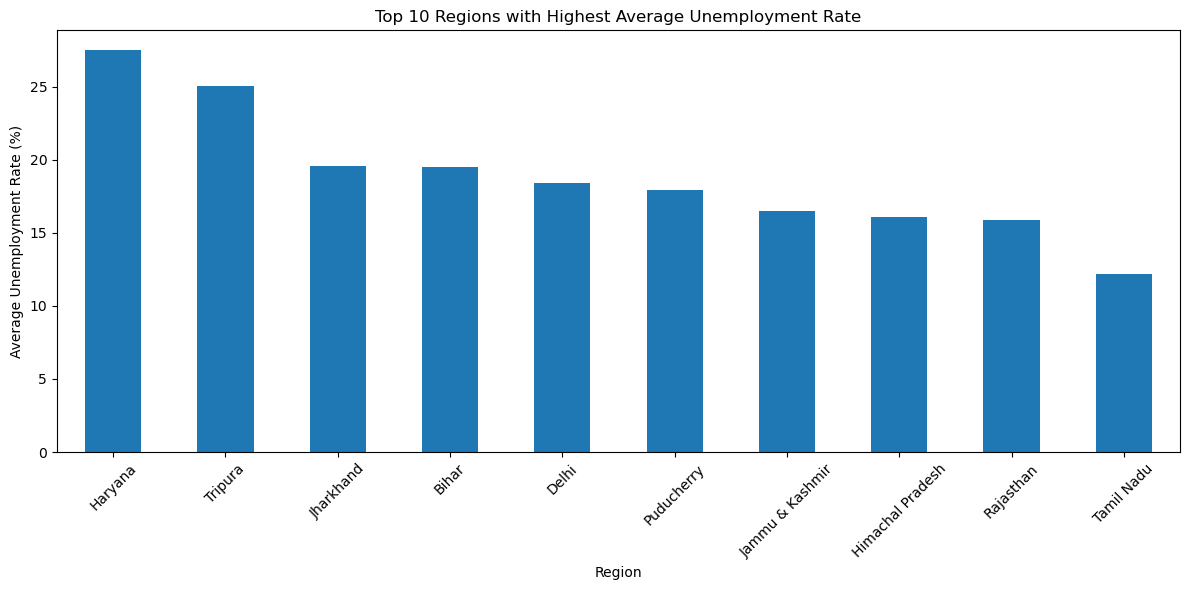

In [17]:
# Plot top 10 regions with highest average unemployment

plt.figure(figsize=(12, 6))

top_10_regions.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

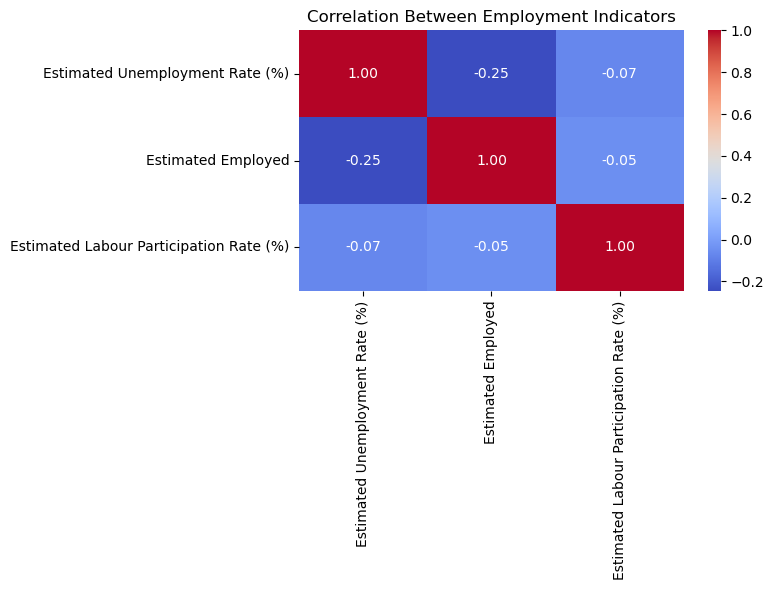

In [18]:
# Select numerical columns for correlation analysis

correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

In [19]:
# Create COVID period categories

df["COVID_Period"] = np.where(
    df["Date"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "Post-COVID"
)

# Calculate average unemployment rate
covid_comparison = df.groupby("COVID_Period")[
    "Estimated Unemployment Rate (%)"
].mean()

print("Average Unemployment Rate:")
print(covid_comparison)

Average Unemployment Rate:
COVID_Period
Post-COVID    12.963860
Pre-COVID      9.231346
Name: Estimated Unemployment Rate (%), dtype: float64


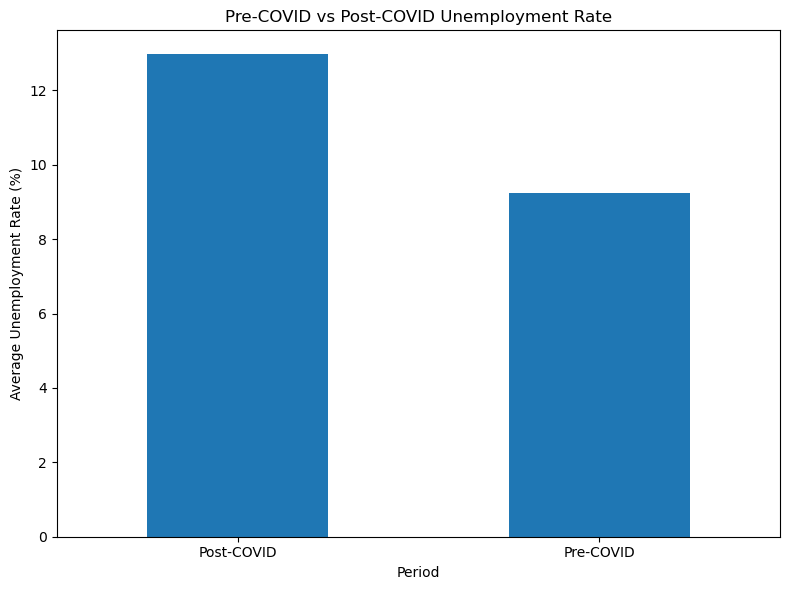

In [20]:
# Plot Pre-COVID vs Post-COVID unemployment rate

plt.figure(figsize=(8, 6))

covid_comparison.plot(kind="bar")

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Observations

- Unemployment rates vary across different regions of India.
- The monthly trend shows changes in unemployment over the study period.
- The selected major regions show different unemployment patterns over time.
- The top 10 analysis identifies the regions with the highest average unemployment rates.
- The correlation heatmap shows the relationships between unemployment, employment, and labour participation.
- The Pre-COVID and Post-COVID comparison helps understand the change in unemployment during the COVID-19 period.

# Conclusion

The Unemployment Analysis project was completed using the Unemployment in India dataset.

The analysis examined:
- Region-wise average unemployment rates
- Monthly unemployment trends
- Unemployment trends for major regions
- Top 10 regions with the highest average unemployment
- Correlation between unemployment, employment, and labour participation
- Pre-COVID and Post-COVID unemployment rates

The analysis shows that unemployment rates varied across regions and over time. The COVID-19 period also provides an important basis for comparing unemployment before and after the pandemic.

Overall, this project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to perform exploratory data analysis and visualize unemployment trends.